<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/notebooks/GVH_BAO_Pipeline_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Objectif

Ce notebook calcule les observables géométriques GVH à partir d’un jeu de données BAO (Baryon Acoustic Oscillations). Il fournit une analyse descriptive et reproductible indépendante de toute interprétation théorique.

2. Imports Python

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8-whitegrid")

3. Chargement des données BAO

Lecture du fichier CSV.

In [ ]:
# Vérifier les fichiers présents dans le répertoire courant

import os
import pandas as pd

print("Répertoire de travail :")
print(os.getcwd())

print("\nFichiers disponibles :")
for fichier in os.listdir():
    print(fichier)

Répertoire de travail :
/content

Fichiers disponibles :
.config
sample_data


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

print("Contenu de MyDrive :")
for f in os.listdir("/content/drive/MyDrive"):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contenu de MyDrive :
sony vio.pdf
CKT.rar
plas mwen.gmap
Classroom
Références et Citations.pdf
Comment paraphraser.pdf
Doc interroge 
Document sans titre (6).gdoc
Document sans titre (5).gdoc
Document sans titre (4).gdoc
Devoir de musique 1.gdoc
Citation des sources et bibliographique.gdoc
Citation des sources et bibliographique.pdf
Portfolio-Module1 (2).gdoc
Portfolio-Module1 (1).gdoc
Portfolio-Module1.gdoc
Projet.gsite
unnamed.jpg
IMG_20220821_110540113.jpg
images (2).jpg
IMG_8673-700x467.jpg
Portfolio-Module2.pdf
Portfolio-Module1.pdf
download (8).jpg
download (2).png
download (3).png
Portfolio-Module3 - Quelques règles d'écriture dun document web.docx.pdf
Portefeuille d'élèves (1).gsite
Menuet en re mineur(1).mp3
Portefeuille d'élèves.gsite
Screencastify
Activité 6.webm
Etape 4.webm
Etape 3.webm
Etape 2.webm
Etape 1.webm
Devoir histoire de l'art.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

bao_path = "/content/drive/MyDrive/sdss_DR12Consensus_bao.dat"

rows = []

with open(bao_path, "r") as f:
    for line in f:
        parts = line.split()

        # garder seulement les lignes du type :
        # z  valeur  observable
        if len(parts) == 3:
            try:
                z = float(parts[0])
                value = float(parts[1])
                observable = parts[2]
                rows.append([z, value, observable])
            except:
                pass

bao = pd.DataFrame(rows, columns=["z", "value", "observable"])

print("Données BAO retenues :")
display(bao)

bao.to_csv("BAO_data.csv", index=False)

print("BAO_data.csv créé avec succès.")
print(os.listdir("/content"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Données BAO retenues :


,z,value,observable


BAO_data.csv créé avec succès.
['.config', 'BAO_data.csv', 'drive', 'sample_data']


In [10]:
bao = pd.read_csv("BAO_data.csv")
bao.head()

,z,value,observable


In [11]:
bao_path = "/content/drive/MyDrive/sdss_DR12Consensus_bao.dat"

with open(bao_path, "r") as f:
    for i in range(40):
        print(i+1, ":", f.readline())

1 : 

2 : 

3 : 

4 : 

5 : 

6 : 

7 : <!DOCTYPE html>

8 : <html

9 :   lang="en"

10 :   

11 :   data-color-mode="auto" data-light-theme="light" data-dark-theme="dark"

12 :   data-a11y-animated-images="system" data-a11y-link-underlines="true"

13 :   

14 :   >

15 : 

16 : 

17 : 

18 : 

19 :   <head>

20 :     <meta charset="utf-8">

21 :   <link rel="dns-prefetch" href="https://github.githubassets.com">

22 :   <link rel="dns-prefetch" href="https://avatars.githubusercontent.com">

23 :   <link rel="dns-prefetch" href="https://github-cloud.s3.amazonaws.com">

24 :   <link rel="dns-prefetch" href="https://user-images.githubusercontent.com/">

25 :   <link rel="preconnect" href="https://github.githubassets.com" crossorigin>

26 :   <link rel="preconnect" href="https://avatars.githubusercontent.com">

27 : 

28 :   

29 : 

30 : 

31 :   <link crossorigin="anonymous" media="all" rel="stylesheet" href="https://github.githubassets.com/assets/light-4fded0090af0ad58.css" /><link cros

In [12]:
import pandas as pd
import urllib.request
import os

url = "https://raw.githubusercontent.com/CobayaSampler/bao_data/master/sdss_DR12Consensus_bao.dat"

raw_path = "sdss_DR12Consensus_bao.dat"

urllib.request.urlretrieve(url, raw_path)

print("Fichier téléchargé :", raw_path)

with open(raw_path, "r") as f:
    for i in range(10):
        print(i+1, ":", f.readline())

Fichier téléchargé : sdss_DR12Consensus_bao.dat
1 : 0.38 1512.39  DM_over_rs

2 : 0.38 81.2087  bao_Hz_rs

3 : 0.51 1975.22  DM_over_rs

4 : 0.51 90.9029  bao_Hz_rs

5 : 0.61 2306.68  DM_over_rs

6 : 0.61 98.9647  bao_Hz_rs

7 : 
8 : 
9 : 
10 : 


In [13]:
bao = pd.read_csv(
    "sdss_DR12Consensus_bao.dat",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["z", "value", "observable"]
)

display(bao)

bao.to_csv("BAO_data.csv", index=False)

print("BAO_data.csv créé avec succès")
print(os.listdir("/content"))

,z,value,observable
0,0.38,1512.3900,DM_over_rs
1,0.38,81.2087,bao_Hz_rs
2,0.51,1975.2200,DM_over_rs
3,0.51,90.9029,bao_Hz_rs
4,0.61,2306.6800,DM_over_rs
5,0.61,98.9647,bao_Hz_rs


BAO_data.csv créé avec succès
['.config', 'sdss_DR12Consensus_bao.dat', 'BAO_data.csv', 'drive', 'sample_data']


In [14]:
import pandas as pd

bao = pd.read_csv("BAO_data.csv")

bao.head()

,z,value,observable
0,0.38,1512.3900,DM_over_rs
1,0.38,81.2087,bao_Hz_rs
2,0.51,1975.2200,DM_over_rs
3,0.51,90.9029,bao_Hz_rs
4,0.61,2306.6800,DM_over_rs


In [15]:
bao.info()
bao.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   z           6 non-null      float64
 1   value       6 non-null      float64
 2   observable  6 non-null      object 
dtypes: float64(2), object(1)
memory usage: 276.0+ bytes


,z,value
count,6.00000,6.000000
mean,0.50000,1010.894383
std,0.10315,1039.499655
min,0.38000,81.208700
25%,0.41250,92.918350
50%,0.51000,805.677350
75%,0.58500,1859.512500
max,0.61000,2306.680000


In [16]:
bao_DM = bao[bao["observable"] == "DM_over_rs"].copy()
bao_Hz = bao[bao["observable"] == "bao_Hz_rs"].copy()

print("BAO distance DM/rs :")
display(bao_DM)

print("BAO expansion H(z)rs :")
display(bao_Hz)

BAO distance DM/rs :


,z,value,observable
0,0.38,1512.39,DM_over_rs
2,0.51,1975.22,DM_over_rs
4,0.61,2306.68,DM_over_rs


BAO expansion H(z)rs :


,z,value,observable
1,0.38,81.2087,bao_Hz_rs
3,0.51,90.9029,bao_Hz_rs
5,0.61,98.9647,bao_Hz_rs


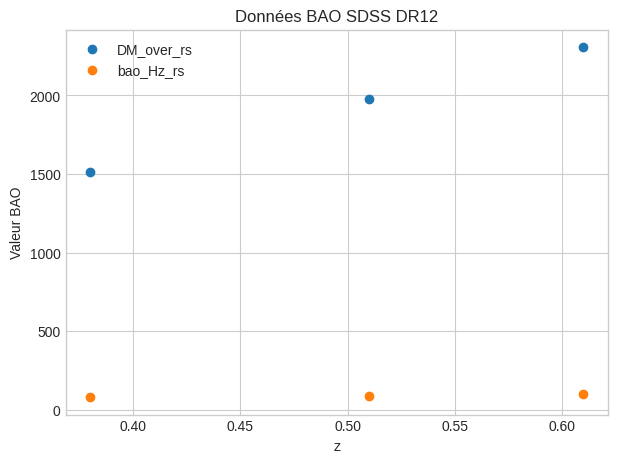

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(bao_DM["z"], bao_DM["value"], label="DM_over_rs")
plt.scatter(bao_Hz["z"], bao_Hz["value"], label="bao_Hz_rs")

plt.xlabel("z")
plt.ylabel("Valeur BAO")
plt.title("Données BAO SDSS DR12")
plt.legend()
plt.show()

In [18]:
import numpy as np
import pandas as pd

def compute_gvh_observables(df, label):
    z = df["z"].values
    y = df["value"].values

    # Tri par redshift
    idx = np.argsort(z)
    z = z[idx]
    y = y[idx]

    # Gradient GVH simple
    D_T = np.abs(np.gradient(y, z))

    # Observables descriptives
    D_T_mean = np.mean(D_T)
    S_T = np.std(D_T)
    D_c = np.percentile(D_T, 90)

    R_super = np.mean(D_T > D_c)

    A_H = np.max(D_T) - np.min(D_T)
    B_H = A_H / (D_T_mean + 1e-12)

    theta_mean = np.nan
    theta_max = np.nan
    R_180 = np.nan

    return pd.DataFrame({
        "Observable": [
            "D_T_mean", "S_T", "D_c", "R_super",
            "A_H", "B_H", "theta_mean", "theta_max", "R_180"
        ],
        "Valeur": [
            D_T_mean, S_T, D_c, R_super,
            A_H, B_H, theta_mean, theta_max, R_180
        ],
        "Dataset": label
    })

summary_DM = compute_gvh_observables(bao_DM, "BAO_DM_over_rs")
summary_Hz = compute_gvh_observables(bao_Hz, "BAO_Hz_rs")

summary_BAO = pd.concat([summary_DM, summary_Hz], ignore_index=True)

summary_BAO

,Observable,Valeur,Dataset
0,D_T_mean,3432.075585,BAO_DM_over_rs
1,S_T,100.562283,BAO_DM_over_rs
2,D_c,3532.463813,BAO_DM_over_rs
3,R_super,0.333333,BAO_DM_over_rs
4,A_H,245.630769,BAO_DM_over_rs
5,B_H,0.071569,BAO_DM_over_rs
6,theta_mean,NaN,BAO_DM_over_rs
7,theta_max,NaN,BAO_DM_over_rs
8,R_180,NaN,BAO_DM_over_rs
9,D_T_mean,77.725846,BAO_Hz_rs


In [19]:
summary_BAO.to_csv("GVH_BAO_Observables.csv", index=False)

print("Export terminé : GVH_BAO_Observables.csv")

Export terminé : GVH_BAO_Observables.csv


In [20]:
pd.read_csv("GVH_BAO_Observables.csv")

,Observable,Valeur,Dataset
0,D_T_mean,3432.075585,BAO_DM_over_rs
1,S_T,100.562283,BAO_DM_over_rs
2,D_c,3532.463813,BAO_DM_over_rs
3,R_super,0.333333,BAO_DM_over_rs
4,A_H,245.630769,BAO_DM_over_rs
5,B_H,0.071569,BAO_DM_over_rs
6,theta_mean,NaN,BAO_DM_over_rs
7,theta_max,NaN,BAO_DM_over_rs
8,R_180,NaN,BAO_DM_over_rs
9,D_T_mean,77.725846,BAO_Hz_rs


## Conclusion

Le notebook `GVH_BAO_Pipeline_0.1` construit un ensemble descriptif d'observables GVH à partir des mesures BAO SDSS DR12.

Les données ont été séparées en deux familles :

- \(D_M/r_s\), liée à la distance transverse comobile ;
- \(H(z)r_s\), liée au taux d'expansion.

Les résultats principaux montrent :

- \(B_H \approx 0.0716\) pour \(D_M/r_s\) ;
- \(B_H \approx 0.0778\) pour \(H(z)r_s\) ;
- \(R_{\rm super} = 0.3333\) pour les deux séries.

Les observables angulaires \(\theta_{\rm mean}\), \(\theta_{\max}\) et \(R_{180}\) ne sont pas évaluées dans cette version, car chaque série BAO ne contient que trois points.

Cette version 0.1 est donc descriptive, reproductible et indépendante de toute interprétation physique. Elle complète les pipelines Pantheon+, H(z) et CMB dans la série GVH Dynamic.